In [4]:
pip install geopy

Defaulting to user installation because normal site-packages is not writeable
  Using cached geopy-2.4.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached geographiclib-2.1-py3-none-any.whl.metadata (1.6 kB)
Using cached geopy-2.4.1-py3-none-any.whl (125 kB)
Using cached geographiclib-2.1-py3-none-any.whl (40 kB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from minio import Minio
from io import BytesIO
from sklearn.ensemble import RandomForestRegressor
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from geopy.distance import geodesic

# Connexion MinIO
client = Minio("localhost:9000",
               access_key="admin",
               secret_key="password123",
               secure=False)

def lire_silver(filename):
    obj = client.get_object("silver", filename)
    return pd.read_csv(BytesIO(obj.read()), low_memory=False)

print("Imports OK !")

Imports OK !


In [6]:
# Charger Silver
gares    = lire_silver("gares_silver.csv")
pois_naq = lire_silver("datatourisme_naq_silver.csv")
festivals= lire_silver("festivals_silver.csv")
freq     = lire_silver("frequentation_silver.csv")

print(f"Gares    : {len(gares)}")
print(f"POIs NAQ : {len(pois_naq)}")
print(f"Festivals: {len(festivals)}")
print(f"Freq     : {len(freq)}")

# Aperçu gares
gares.head()

Gares    : 2782
POIs NAQ : 89106
Festivals: 3134
Freq     : 227400


,nom_gare,code_commune,code_uic,latitude,longitude
0,Aubigny-au-Bac,59026,87345447,50.268532,3.158706
1,Bains-les-Bains,88108,87144147,47.981128,6.295268
2,Biganos Facture,33051,87582478,44.637384,-0.966210
3,Ars-sur-Moselle,57032,87192401,49.074475,6.077646
4,Ax-les-Thermes,9032,87611533,42.724797,1.833252


Top 15 catégories POIs NAQ :
categorie
Accommodation            22836
CulturalEvent            12336
SportsAndLeisurePlace     8792
FoodEstablishment         8589
CulturalSite              6871
Store                     4417
Tour                      3070
CyclingTour               2703
Producer                  2700
CraftsmanShop             1630
ConvenientService         1583
LocalAnimation            1423
SaleEvent                 1318
Practice                  1114
MedicalPlace               932
Name: count, dtype: int64


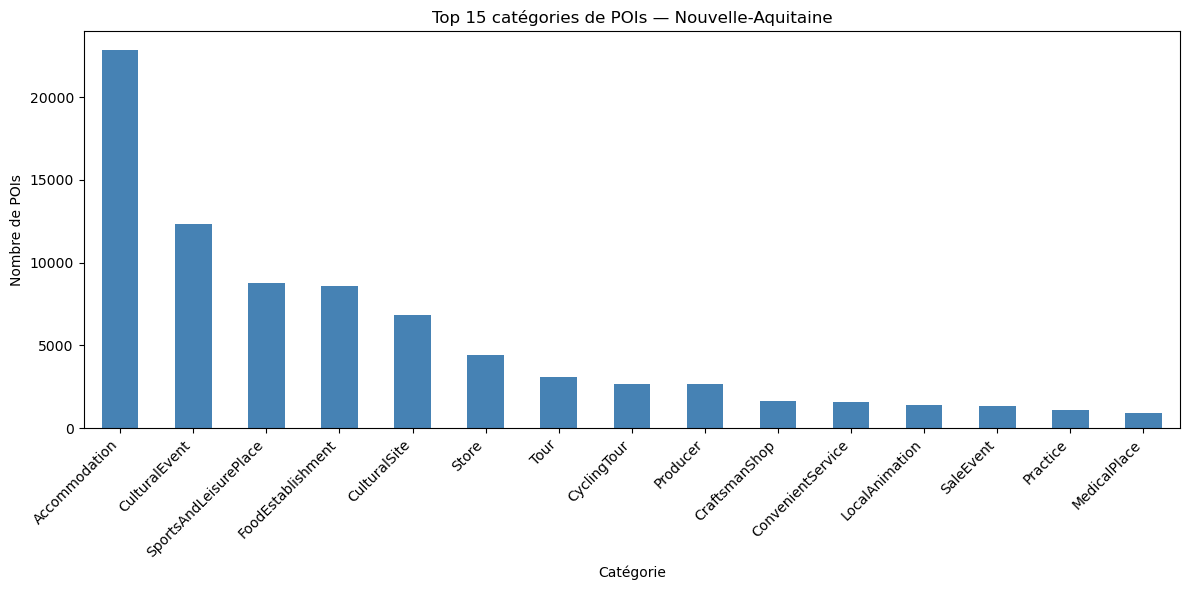

Graphique sauvegardé !


In [7]:
# Quelles catégories de POIs on a ?
top_categories = pois_naq['categorie'].value_counts().head(15)
print("Top 15 catégories POIs NAQ :")
print(top_categories)

# Graphique
plt.figure(figsize=(12, 6))
top_categories.plot(kind='bar', color='steelblue')
plt.title("Top 15 catégories de POIs — Nouvelle-Aquitaine")
plt.xlabel("Catégorie")
plt.ylabel("Nombre de POIs")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("categories_pois.png")
plt.show()
print("Graphique sauvegardé !")

In [8]:
# POIs autour de Limoges (rayon 20km)
LIMOGES_LAT = 45.8336
LIMOGES_LON = 1.2611

pois_limoges = []
for _, poi in pois_naq.iterrows():
    try:
        dist = geodesic(
            (LIMOGES_LAT, LIMOGES_LON),
            (poi['latitude'], poi['longitude'])
        ).km
        if dist <= 20:
            pois_limoges.append({
                'nom'      : poi['nom_poi'],
                'categorie': poi['categorie'],
                'latitude' : poi['latitude'],
                'longitude': poi['longitude'],
                'distance' : round(dist, 2)
            })
    except:
        pass

df_limoges = pd.DataFrame(pois_limoges)
print(f"POIs autour de Limoges (20km) : {len(df_limoges)}")
print("\nTop catégories à Limoges :")
print(df_limoges['categorie'].value_counts().head(10))

POIs autour de Limoges (20km) : 2201

Top catégories à Limoges :
categorie
CulturalEvent            458
Accommodation            407
FoodEstablishment        352
CulturalSite             193
SportsAndLeisurePlace    143
CyclingTour              119
Store                    104
CraftsmanShop             60
Practice                  45
Conference                37
Name: count, dtype: int64


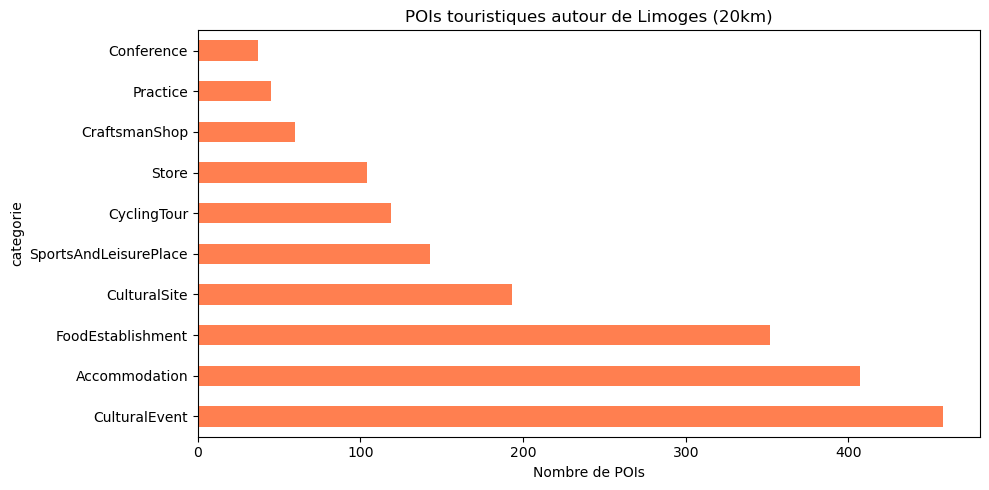

In [9]:
# Graphique POIs Limoges
cats_limoges = df_limoges['categorie'].value_counts().head(10)

plt.figure(figsize=(10, 5))
cats_limoges.plot(kind='barh', color='coral')
plt.title("POIs touristiques autour de Limoges (20km)")
plt.xlabel("Nombre de POIs")
plt.tight_layout()
plt.savefig("pois_limoges.png")
plt.show()

       ville  distance  train_kg  voiture_kg  avion_kg
0    Limoges       346      2.08       67.48     98.62
1   Bordeaux       499      3.00       97.40    142.35
2       Lyon       392      2.35       76.38    111.64
3  Marseille       660      3.96      128.80    188.24
4   Toulouse       588      3.53      114.65    167.57
5     Nantes       343      2.06       66.98     97.89
6     Rennes       309      1.85       60.25     88.06


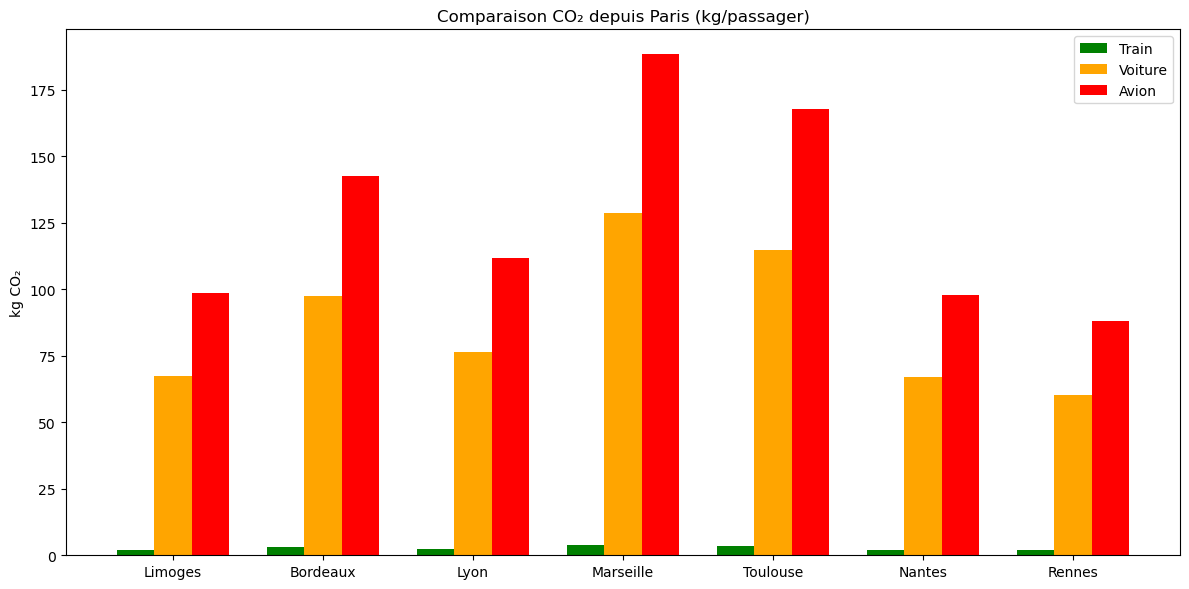

In [10]:
# Comparateur CO₂
CO2_TRAIN   =   6   # g/km
CO2_VOITURE = 195   # g/km
CO2_AVION   = 285   # g/km

villes = {
    'Limoges' : (45.8336, 1.2611),
    'Bordeaux': (44.8378, -0.5792),
    'Lyon'    : (45.7640, 4.8357),
    'Marseille': (43.2965, 5.3698),
    'Toulouse': (43.6047, 1.4442),
    'Nantes'  : (47.2184, -1.5536),
    'Rennes'  : (48.1173, -1.6778),
}

PARIS = (48.8566, 2.3522)

resultats = []
for ville, coords in villes.items():
    dist = geodesic(PARIS, coords).km
    resultats.append({
        'ville'     : ville,
        'distance'  : round(dist),
        'train_kg'  : round(dist * CO2_TRAIN / 1000, 2),
        'voiture_kg': round(dist * CO2_VOITURE / 1000, 2),
        'avion_kg'  : round(dist * CO2_AVION / 1000, 2),
    })

df_co2 = pd.DataFrame(resultats)
print(df_co2.to_string())

# Graphique CO₂
fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(df_co2))
width = 0.25

ax.bar([i-width for i in x], df_co2['train_kg'],
       width, label='Train', color='green')
ax.bar(x, df_co2['voiture_kg'],
       width, label='Voiture', color='orange')
ax.bar([i+width for i in x], df_co2['avion_kg'],
       width, label='Avion', color='red')

ax.set_xticks(list(x))
ax.set_xticklabels(df_co2['ville'])
ax.set_title("Comparaison CO₂ depuis Paris (kg/passager)")
ax.set_ylabel("kg CO₂")
ax.legend()
plt.tight_layout()
plt.savefig("comparaison_co2.png")
plt.show()

In [12]:
# Lire les résultats Gold
def lire_gold(filename):
    obj = client.get_object("gold", filename)
    return pd.read_csv(BytesIO(obj.read()), low_memory=False)

scores = lire_gold("score_touristique.csv")
clusters = lire_gold("clustering_gares.csv")
co2 = lire_gold("comparaison_co2.csv")

print("=== Top 10 Score Touristique ===")
print(scores.nlargest(10, 'score_rf')[
    ['nom_gare', 'nb_pois', 'score_rf']
].to_string())

print("\n=== Limoges ===")
print(scores[scores['nom_gare'].str.contains(
    'Limoges', case=False, na=False
)].to_string())
# Corriger nb_festivals pour Limoges
festivals_naq = festivals[
    festivals['region'].str.contains(
        'Nouvelle-Aquitaine', na=False, case=False
    )
]
print(f"Festivals en Nouvelle-Aquitaine : {len(festivals_naq)}")
print(festivals_naq[['nom_festival', 'commune', 'domaine']].head(10))

=== Top 10 Score Touristique ===
                 nom_gare  nb_pois  score_rf
21     Paris Montparnasse     6624      99.7
39                Puteaux     6604      99.5
22     Paris Saint-Lazare     6554      99.0
24     Paris Gare du Nord     6503      98.2
23              Paris Est     6501      98.1
54   Chaville Rive Droite     6467      97.7
86      La Barre Ormesson     6384      96.5
27       Paris Austerlitz     6343      95.9
20     Paris Gare de Lyon     6248      94.6
1   Cormeilles-en-Parisis     6133      92.9

=== Limoges ===
               nom_gare   latitude  longitude  nb_pois  nb_festivals  score_touristique  score_rf
13  Limoges Bénédictins  45.836089   1.267356     2179             0               32.9      32.3
16    Limoges Montjovis  45.838412   1.251415     2251             0               34.0      32.7
Festivals en Nouvelle-Aquitaine : 362
                         nom_festival              commune  \
1              CHANTONS SOUS LES PINS  Pontonx sur l Adour   

In [14]:
# Festivals autour de Limoges (50km)
LIMOGES_LAT = 45.8336
LIMOGES_LON = 1.2611

festivals_limoges = []
for _, fest in festivals.iterrows():
    try:
        dist = geodesic(
            (LIMOGES_LAT, LIMOGES_LON),
            (fest['latitude'], fest['longitude'])
        ).km
        if dist <= 50:
            festivals_limoges.append(fest)
    except:
        pass

df_fest_limoges = pd.DataFrame(festivals_limoges)
print(f"Festivals autour de Limoges (50km) : {len(df_fest_limoges)}")
print(df_fest_limoges[['nom_festival', 'commune', 'domaine']].to_string())

Festivals autour de Limoges (50km) : 21
                                nom_festival                  commune                              domaine
176                           Graines de Rue    Bessines sur Gartempe             Cirque et Arts de la rue
266                                CATALACUM                CHAPTELAT                   Musiques actuelles
792                       Festival de Bellac                   BELLAC  Pluridisciplinaire Spectacle vivant
895   Festival des francophonies en Limousin                  LIMOGES  Pluridisciplinaire Spectacle vivant
1035                 ZIC A NOUIC (ZICANOUIC)                    Nouic                   Musiques actuelles
1364                        SCENES D'AUTOMNE  ST MAURICE LES BROUSSES                   Musiques actuelles
1489                         CUIVRES EN FÊTE                  LIMOGES                   Musiques actuelles
1537                          Lire à Limoges                  LIMOGES                 Livre et littératu

In [15]:
# Score Limoges avec vraies données
nb_pois_limoges     = 2179   # déjà calculé
nb_festivals_limoges = 21    # vrai nombre !

score_limoges = (nb_pois_limoges * 0.7 + nb_festivals_limoges * 2)
print(f"POIs autour de Limoges    : {nb_pois_limoges}")
print(f"Festivals autour Limoges  : {nb_festivals_limoges}")
print(f"Score brut                : {score_limoges}")

# Comparer avec Paris
nb_pois_paris     = 6624
nb_festivals_paris = 399
score_paris = (nb_pois_paris * 0.7 + nb_festivals_paris * 2)

# Normaliser
score_limoges_final = round(score_limoges / score_paris * 100, 1)
print(f"\nScore Limoges : {score_limoges_final}/100")
print(f"Score Paris   : 100/100")
print(f"\nConclusion : Limoges a {score_limoges_final}% de l'attractivité de Paris")
print(f"→ Ville sous-estimée qui mérite plus de visiteurs !")

POIs autour de Limoges    : 2179
Festivals autour Limoges  : 21
Score brut                : 1567.3

Score Limoges : 28.8/100
Score Paris   : 100/100

Conclusion : Limoges a 28.8% de l'attractivité de Paris
→ Ville sous-estimée qui mérite plus de visiteurs !
